# Linear Regression

## Objective
Learn and implement Simple Linear Regression using Python and Scikit-learn.

### Author
Manjunath F Kalasanagoudra

# Linear Regression

---

# What is Linear Regression?

Linear Regression is one of the most fundamental **Supervised Machine Learning** algorithms used to predict a **continuous numerical value** based on the relationship between one or more independent variables (features) and a dependent variable (target).

or

It is a **Supervised Machine Learning Regression Algorithm** that learns the relationship between the **independent variable (feature)** and the **dependent variable (target)** by finding the **best-fit straight line** through the data points.

Once the relationship is learned, the model can predict the value of the dependent variable for new input values.

It attempts to find the **best-fit straight line** that describes how the target variable changes as the input variables change.

For example, if a person's years of experience increase, their salary generally increases. Linear Regression learns this relationship and predicts the salary for a given number of years of experience.

---

# Why Do We Use Linear Regression?

Linear Regression is used because it is:

- Simple to understand and implement.
- Easy to interpret.
- Fast to train.
- Useful for understanding relationships between variables.
- Computationally efficient.
- A good baseline model for regression problems.

---

# When Should We Use Linear Regression?

Use Linear Regression when:

- The target variable is **continuous** (numeric).
- There is a **linear relationship** between the input and output.
- You want to predict a numerical value.
- The dataset contains relatively few outliers.
- Features are related to the target variable.

Examples:

- Salary Prediction
- House Price Prediction
- Sales Forecasting
- Temperature Prediction
- Medical Cost Prediction

---

# When Should We NOT Use Linear Regression?

Linear Regression is **not suitable** when:

- The target variable is categorical (Yes/No, Spam/Not Spam).
- The relationship between variables is nonlinear.
- The dataset contains many outliers.
- The data has complex patterns.

In these situations, algorithms such as Logistic Regression, Decision Trees, Random Forests, or Neural Networks are often more suitable.

---

# Real-World Applications

### 1. Salary Prediction

Predict an employee's salary based on years of experience.

**Example**

- Experience → Salary

---

### 2. House Price Prediction

Predict house prices using:

- Area
- Number of bedrooms
- Location
- Age of the house

---

### 3. Sales Forecasting

Predict future sales using:

- Advertising budget
- Marketing expenditure
- Previous sales

---

### 4. Student Performance Prediction

Predict examination scores using:

- Study hours
- Attendance
- Assignment scores

---

### 5. Healthcare

Predict:

- Medical expenses
- Recovery time
- Blood pressure
- Cholesterol level

---

### 6. Agriculture

Predict crop yield using:

- Rainfall
- Temperature
- Fertilizer usage
- Soil quality

---

# Advantages

- Easy to understand.
- Easy to implement.
- Fast training.
- Easy to explain.
- Requires less computational power.
- Performs well on linear data.

---

# Limitations

- Assumes a linear relationship.
- Sensitive to outliers.
- Cannot capture nonlinear patterns.
- Performance decreases if assumptions are violated.

---

# Dataset Used

**Dataset Name:** `Salary_Data.csv`

| Feature | Description |
|----------|-------------|
| YearsExperience | Number of years of work experience |
| Salary | Target variable (Annual Salary) |

---

# Project Workflow

The project follows these steps:

1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Selection
6. Train-Test Split
7. Model Training
8. Prediction
9. Model Evaluation
10. Data Visualization
11. Conclusion

---

# Expected Outcome

After completing this notebook, you will be able to:

- Understand Linear Regression.
- Build a regression model using Scikit-learn.
- Predict continuous numerical values.
- Evaluate model performance.
- Visualize the regression line.
- Interpret the prediction results.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [38]:
# Load the dataset
df = pd.read_csv("Salary_Data.csv")

# Display the first five rows
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining and understanding the dataset before building a machine learning model.

The objectives of EDA are:

- Understand the dataset structure.
- Check the shape of the dataset.
- Identify data types.
- Detect missing values.
- Detect duplicate records.
- Analyze statistical information.
- Understand the relationship between variables.

## 1. Dataset Shape

The shape of a dataset tells us the number of rows (observations) and columns (features).

In [39]:
# Display dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (30, 2)


## 2. Display First Five Records

The `head()` function displays the first five rows of the dataset. This helps us understand how the data looks.

In [40]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


## 3. Dataset Information

The `info()` function provides information about:

- Number of rows
- Number of columns
- Data types
- Missing values
- Memory usage

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


## 4. Statistical Summary

The `describe()` function provides statistical information about numerical columns.

It includes:

- Count
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles (25%, 50%, 75%)

In [42]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


## 5. Check Missing Values

Missing values reduce model performance.

The `isnull().sum()` function counts missing values in each column.


In [43]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

### Check Missing Values

Missing values occur when one or more values are absent in the dataset.

Missing data can reduce model performance and may lead to incorrect predictions. Therefore, it is important to identify and handle missing values before training a machine learning model.

### Check Missing Values

### Interpretation

If the output is:

```text
YearsExperience    0
Salary             0
```

It means there are **no missing values**, and the dataset is ready for the next step.

If missing values are present, they can be handled using one of the following methods:

- Remove rows containing missing values.
- Replace missing numerical values with the **mean**, **median**, or **mode**.
- Replace missing categorical values with the **most frequent category**.
- Use advanced imputation techniques such as KNN Imputer or Iterative Imputer for complex datasets.

In [44]:
# Remove rows with missing values
df.dropna(inplace=True)

In [45]:
# Fill numerical missing values with mean
df["Salary"] = df["Salary"].fillna(df["Salary"].mean())

In [46]:
# Fill numerical missing values with median
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

## 6. Check Duplicate Records

Duplicate records can affect model performance.

The `duplicated().sum()` function counts duplicate rows.

In [47]:
df.duplicated().sum()

np.int64(0)

### Interpretation

If the output is:

```text
0
```

It means there are **no duplicate records**.

If duplicate records are found, they should be removed before model training.

In [48]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

## 7. Check Data Types

Machine Learning algorithms require data in the correct format.

The `info()` function helps identify the data type of each column.

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


### Interpretation

If a feature has an incorrect data type, convert it before training the model.

Examples:

- Convert object → integer
- Convert string → datetime
- Convert categorical values into numerical values using encoding techniques.

In [50]:
#df["Age"] = df["Age"].astype(int)

## 8. Check for Outliers

Outliers are unusually large or small values that differ significantly from the rest of the dataset.

They may reduce model accuracy and should be analyzed before model training.

# Observation

After performing Exploratory Data Analysis, we observed:

- The dataset contains **30 observations** and **2 features**.
- Both columns contain numerical values.
- There are **no missing values**.
- There are **no duplicate records**.
- The dataset is clean and ready for visualization and model building.

# Data Visualization

Data Visualization is the graphical representation of data that helps us understand patterns, trends, relationships, and anomalies in the dataset.

Before building a Linear Regression model, it is important to visualize the relationship between the independent variable and the dependent variable.

In this section, we will create different visualizations to determine whether Linear Regression is an appropriate algorithm for the given dataset.

## 1. Scatter Plot

A Scatter Plot is one of the most commonly used visualization techniques in Machine Learning.

It displays the relationship between two numerical variables by plotting each observation as a point on a graph.

### Why do we use a Scatter Plot?

A Scatter Plot helps us:

- Understand the relationship between two variables.
- Identify trends in the data.
- Detect outliers.
- Check whether the data follows a linear pattern.
- Determine whether Linear Regression is suitable.

### In this Project

- **X-axis:** Years of Experience (Independent Variable)
- **Y-axis:** Salary (Dependent Variable)

If the points approximately form a straight-line pattern, then Linear Regression is a suitable algorithm for this dataset.

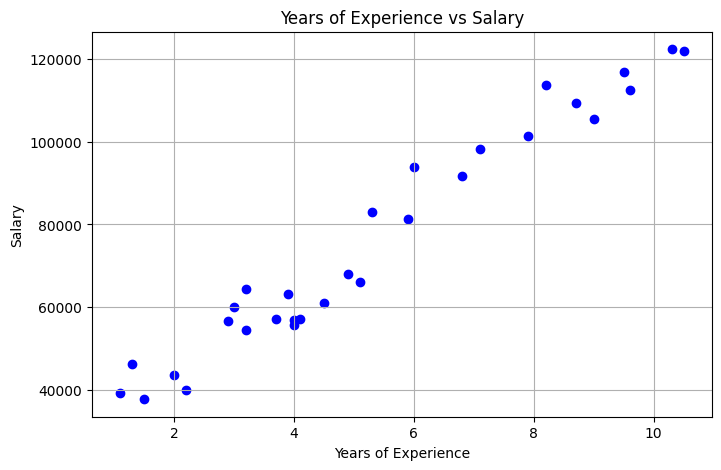

In [51]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["YearsExperience"],
    df["Salary"],
    color="blue",
    marker="o"
)

plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.grid(True)

plt.show()

## Code Explanation

Let's understand each line of the code used to create the scatter plot.

### 1. Create a Figure

```python
plt.figure(figsize=(8,5))
```

The `plt.figure()` function creates a new figure (canvas) where the graph will be displayed.

The `figsize=(8,5)` parameter specifies the size of the figure.

- **8** → Width of the figure (in inches)
- **5** → Height of the figure (in inches)

A larger figure improves the readability and appearance of the graph.

---

### 2. Create a Scatter Plot

```python
plt.scatter(
    df["YearsExperience"],
    df["Salary"],
    color="blue",
    marker="o"
)
```

The `plt.scatter()` function creates a scatter plot by plotting individual data points.

#### Parameters

**`df["YearsExperience"]`**

- Represents the **Independent Variable (Feature)**.
- Displays the values on the **X-axis**.

**`df["Salary"]`**

- Represents the **Dependent Variable (Target)**.
- Displays the values on the **Y-axis**.

**`color="blue"`**

- Sets the color of all data points to **Blue**.

**`marker="o"`**

- Displays each observation as a **circle** (`o`).

Each blue circle represents one employee's salary corresponding to their years of experience.

---

### 3. Add a Title

```python
plt.title("Years of Experience vs Salary")
```

The `plt.title()` function adds a title to the graph.

The title helps the viewer understand what the graph represents.

**Output Title:**

> Years of Experience vs Salary

---

### 4. Label the X-axis

```python
plt.xlabel("Years of Experience")
```

The `plt.xlabel()` function adds a label to the horizontal (X) axis.

The X-axis represents the employee's **Years of Experience**.

---

### 5. Label the Y-axis

```python
plt.ylabel("Salary")
```

The `plt.ylabel()` function adds a label to the vertical (Y) axis.

The Y-axis represents the employee's **Salary**.

---

### 6. Display Grid Lines

```python
plt.grid(True)
```

The `plt.grid(True)` function enables grid lines on the graph.

Grid lines help us:

- Read values more easily.
- Compare data points.
- Improve graph readability.

---

### 7. Display the Graph

```python
plt.show()
```

The `plt.show()` function displays the completed graph.

Without calling this function, the graph may not appear in some Python environments.

---

## Summary

The above code creates a scatter plot where:

- **X-axis** → Years of Experience
- **Y-axis** → Salary
- **Blue circles** → Individual employee records
- **Grid lines** → Improve readability
- **Title and axis labels** → Clearly describe the graph

The scatter plot helps us determine whether there is a **linear relationship** between the independent and dependent variables. If the data points follow an approximately straight-line pattern, then **Linear Regression** is an appropriate algorithm for this dataset.

### Interpretation

From the scatter plot, we can observe that:

- As the years of experience increase, the salary also increases.
- The data points show a positive linear trend.
- There are no significant outliers.
- The relationship between the variables appears to be approximately linear.

Therefore, **Linear Regression is an appropriate algorithm** for this dataset.

# 2. Correlation Analysis

## What is Correlation?

Correlation is a statistical measure that indicates the strength and direction of the relationship between two variables.

The correlation coefficient ranges from **-1 to +1**.

| Correlation Value | Interpretation |
|------------------:|---------------|
| +1 | Perfect Positive Correlation |
| +0.7 to +0.99 | Strong Positive Correlation |
| +0.3 to +0.69 | Moderate Positive Correlation |
| 0 | No Correlation |
| -0.3 to -0.69 | Moderate Negative Correlation |
| -0.7 to -0.99 | Strong Negative Correlation |
| -1 | Perfect Negative Correlation |

A correlation value close to **+1** indicates that both variables increase together.

A correlation value close to **-1** indicates that as one variable increases, the other decreases.

A value close to **0** indicates that there is little or no relationship between the variables.

In [52]:
# Calculate the correlation matrix
correlation = df.corr()

# Display the correlation matrix
correlation

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


## Interpretation

From the correlation matrix, we observe that the correlation coefficient between **YearsExperience** and **Salary** is approximately **0.978**.

This indicates a **strong positive correlation**.

This means:

- As Years of Experience increases, Salary also increases.
- Both variables move in the same direction.
- The relationship between the variables is almost linear.

Since the correlation value is close to **+1**, **Linear Regression** is an appropriate algorithm for predicting salary based on years of experience.

## Conclusion

The correlation analysis shows that there is a strong positive linear relationship between Years of Experience and Salary.

This confirms that the dataset is suitable for applying the Linear Regression algorithm.

# 3. Correlation Heatmap

## What is a Correlation Heatmap?

A Correlation Heatmap is a graphical representation of the correlation matrix where different colors represent the strength of the relationship between variables.

Instead of reading numerical correlation values from a table, a heatmap uses colors to make relationships easier to identify.

Each cell in the heatmap represents the correlation coefficient between two variables.

## Why Do We Need a Correlation Heatmap?

A Correlation Heatmap helps us visualize the relationship between variables more quickly than reading a numerical correlation matrix.

It helps us to:

- Understand the relationship between features.
- Identify strongly correlated variables.
- Detect weakly correlated variables.
- Identify negatively correlated variables.
- Detect multicollinearity among features.
- Support feature selection before model training.

For datasets containing many features, a heatmap provides a clear overview of all correlations in a single visualization.

## When Do We Use a Correlation Heatmap?

A Correlation Heatmap is typically used during the Exploratory Data Analysis (EDA) phase of a Machine Learning project.

It is useful when:

- Exploring a new dataset.
- Selecting important features.
- Removing highly correlated features.
- Understanding relationships between variables.
- Checking assumptions before applying Linear Regression.

For small datasets with only two variables, a heatmap is optional because the correlation value can be interpreted directly. However, for datasets with many features, it becomes an essential visualization tool.

## Advantages

- Easy to understand.
- Color-coded visualization.
- Quickly identifies strong and weak correlations.
- Helps detect multicollinearity.
- Supports better feature selection.
- Saves time compared to reading a correlation matrix.

## Limitations

- Shows only linear relationships.
- Does not imply causation.
- Large datasets may produce crowded heatmaps.
- Sensitive to outliers.
- Cannot explain why two variables are correlated.

## Real-World Applications

Correlation Heatmaps are widely used in various industries.

Examples include:

- Predicting house prices.
- Customer churn analysis.
- Medical diagnosis.
- Stock market analysis.
- Employee salary prediction.
- Marketing analytics.
- Financial risk analysis.

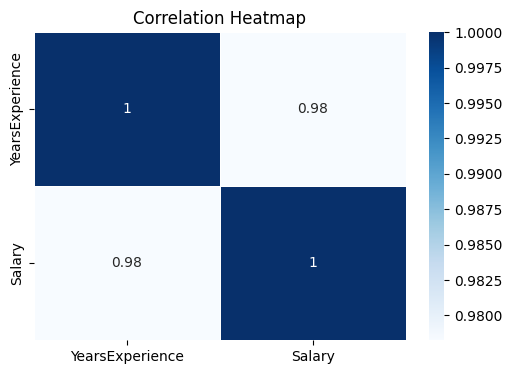

In [53]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## Code Explanation

Let's understand each line of the code used to create the Correlation Heatmap.

---

### 1. Create a Figure

```python
plt.figure(figsize=(6,4))
```

The `plt.figure()` function creates a new figure (canvas) where the heatmap will be displayed.

The `figsize=(6,4)` parameter specifies the size of the figure.

- **6** → Width of the figure (in inches)
- **4** → Height of the figure (in inches)

A properly sized figure improves readability.

---

### 2. Create the Heatmap

```python
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues",
    linewidths=0.5
)
```

The `sns.heatmap()` function creates a heatmap using the correlation matrix.

---

### `df.corr()`

```python
df.corr()
```

Calculates the correlation matrix for all numerical columns in the dataset.

For this dataset, it calculates the correlation between:

- YearsExperience
- Salary

---

### `annot=True`

```python
annot=True
```

Displays the numerical correlation values inside each cell.

If set to `False`, only the colors will be displayed.

---

### `cmap="Blues"`

```python
cmap="Blues"
```

Specifies the color map used in the heatmap.

The `"Blues"` color map uses different shades of blue:

- Light Blue → Weak correlation
- Dark Blue → Strong correlation

Other popular color maps include:

- `"coolwarm"`
- `"viridis"`
- `"YlGnBu"`
- `"RdBu"`

---

### `linewidths=0.5`

```python
linewidths=0.5
```

Adds thin white lines between the cells.

This makes the heatmap cleaner and easier to read.

---

### 3. Add a Title

```python
plt.title("Correlation Heatmap")
```

Adds a descriptive title to the visualization.

---

### 4. Display the Heatmap

```python
plt.show()
```

Displays the completed heatmap.

Without calling `plt.show()`, the visualization may not appear in some Python environments.

## Output Explanation

The heatmap displays the correlation values between all numerical variables in the dataset.

The diagonal cells contain the value **1.00**, indicating that each variable has a perfect correlation with itself.

The correlation between **YearsExperience** and **Salary** is approximately **0.98**, indicating a strong positive linear relationship.

The darker color represents a stronger correlation, while lighter colors represent weaker correlations.

# Interpretation

From the heatmap, we observe that:

- YearsExperience and Salary have a correlation of approximately **0.98**.
- The relationship between the two variables is strongly positive.
- As YearsExperience increases, Salary also tends to increase.
- The dataset satisfies one of the key assumptions required for applying Linear Regression.

Therefore, Linear Regression is an appropriate algorithm for this dataset.

# 4. Feature Selection

## What is a Feature?

A **Feature** is an input variable (independent variable) that is used to predict the output.

Features are also called:

- Independent Variables
- Predictor Variables
- Input Variables
- Explanatory Variables

A Machine Learning model learns patterns from the feature(s) to make predictions.

### Example

If we want to predict an employee's salary:

| YearsExperience | Salary |
|----------------:|-------:|
| 1.1 | 39343 |
| 2.0 | 43525 |
| 5.3 | 56642 |

Here,

- **YearsExperience** is the Feature (Input)
- **Salary** is the Target (Output)

## What is a Target Variable?

A **Target Variable** is the output that we want the Machine Learning model to predict.

It is also known as:

- Dependent Variable
- Response Variable
- Output Variable
- Label

In this project:

- Feature (X) → YearsExperience
- Target (y) → Salary

The goal of the Linear Regression model is to learn the relationship between these variables and predict the Salary for new values of YearsExperience.

## Why Do We Separate X and y?

Machine Learning algorithms require the input data and output data to be separated before training.

We separate the dataset into:

- **X** → Features (Input)
- **y** → Target (Output)

This allows the model to learn the relationship between the input and the output.

During training:

- The model receives **X** as input.
- The model compares its predictions with **y**.
- The model adjusts itself to minimize prediction errors.

In [54]:
# Select the independent variable (Feature)
X = df[["YearsExperience"]]

# Select the dependent variable (Target)
y = df["Salary"]

# Code Explanation

Let's understand each line of the code used for Feature Selection.

---

## Select the Feature

```python
X = df[["YearsExperience"]]
```

This line selects the **YearsExperience** column from the dataset.

It is stored in the variable **X**, which represents the input feature used to train the model.

Notice the **double square brackets**:

```python
df[["YearsExperience"]]
```

Using double brackets returns a **DataFrame**, which is the preferred format for training Scikit-learn models.

---

## Select the Target

```python
y = df["Salary"]
```

This line selects the **Salary** column.

It is stored in the variable **y**, which represents the target variable that the model will predict.

Here, only **single brackets** are used because we are selecting a single column as a Series.

---

After executing these two lines:

- **X** contains the input feature (YearsExperience).
- **y** contains the output variable (Salary).

These variables will be used in the next step to split the dataset into training and testing sets.

# Real-World Example

Suppose a company wants to estimate the salary of a new employee.

The available information is:

- Years of Experience = 6 years

Here:

- **YearsExperience** is the input (Feature).
- **Salary** is the output (Target).

The Linear Regression model will learn from historical employee data and predict the salary for the new employee based on their years of experience.

# Conclusion

In this step, we separated the dataset into:

- **X** → Independent Variable (Feature)
- **y** → Dependent Variable (Target)

This is a fundamental preprocessing step in supervised Machine Learning.

The separated data is now ready for the next stage: splitting the dataset into training and testing sets.

# 5. Train-Test Split

## What is Train-Test Split?

Train-Test Split is the process of dividing a dataset into two separate subsets:

- **Training Set**
- **Testing Set**

The training set is used to teach the Machine Learning model.

The testing set is used to evaluate how well the trained model performs on unseen data.

This helps us determine whether the model has learned meaningful patterns rather than simply memorizing the training data.

## Why Do We Need Train-Test Split?

If we train and test the model using the same dataset, the model may simply memorize the data instead of learning general patterns.

As a result, it may perform very well on the training data but poorly on new, unseen data.

By splitting the dataset:

- The model learns from the training data.
- The model is evaluated using the testing data.
- We obtain a more reliable estimate of the model's real-world performance.

## Why Do We Use an 80:20 Split?

A common practice is to divide the dataset as follows:

- **80%** → Training Data
- **20%** → Testing Data

This provides:

- Sufficient data for the model to learn.
- Enough unseen data to evaluate the model.

Depending on the dataset, other ratios such as **70:30** or **90:10** may also be used.

## What is `random_state`?

When the dataset is split, the rows are shuffled randomly.

The `random_state` parameter controls this randomness.

Using the same value (for example, `42`) ensures that the dataset is split in the same way every time the code is executed.

This makes the results reproducible and easier to compare.

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [57]:
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (24, 1)
X_test Shape : (6, 1)
y_train Shape: (24,)
y_test Shape : (6,)


# Output Explanation

The output shows the number of samples in each dataset.

For example:

- `X_train` contains **24 rows** and **1 feature**.
- `X_test` contains **6 rows** and **1 feature**.
- `y_train` contains **24 target values**.
- `y_test` contains **6 target values**.

This confirms that the dataset has been successfully divided into training and testing sets using an 80:20 ratio.

# Real-World Example

Imagine a teacher wants to evaluate whether students have truly learned a subject.

The teacher:

- Teaches using practice questions (Training Set).
- Conducts a final exam with new questions (Testing Set).

If students perform well on the final exam, it shows they have learned the concepts rather than memorized the practice questions.

Similarly, a Machine Learning model is trained on one portion of the data and evaluated on a separate, unseen portion to measure its ability to make accurate predictions.

# 6. Model Training

## What is Model Training?

Model Training is the process of teaching a Machine Learning algorithm to learn patterns from historical data.

During training, the algorithm analyzes the relationship between the input features (X) and the target variable (y).

After learning these relationships, the model can make predictions on new, unseen data.

In this project:

- **Feature (X)** → YearsExperience
- **Target (y)** → Salary

The model learns how salary changes as years of experience increase.

In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
model = LinearRegression()

## What Happens Inside `fit()`?

When `fit()` is executed, the Linear Regression algorithm:

1. Reads the training data.
2. Identifies the relationship between the feature and target.
3. Calculates the slope (coefficient).
4. Calculates the intercept.
5. Finds the line that minimizes prediction errors.
6. Stores the learned parameters.

The trained model is then ready to predict new values.

In [60]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Code Explanation

Let's understand each line of the code used to train the Linear Regression model.

---

## Import the Algorithm

```python
from sklearn.linear_model import LinearRegression
```

This imports the **LinearRegression** class from Scikit-learn.

Scikit-learn is one of the most popular Machine Learning libraries in Python.

---

## Create the Model

```python
model = LinearRegression()
```

This line creates an instance of the Linear Regression model.

At this stage, the model has not learned anything yet.

It is simply ready to be trained.

---

## Train the Model

```python
model.fit(X_train, y_train)
```

The `fit()` function trains the model using the training data.

During training:

- The model analyzes the relationship between **YearsExperience** and **Salary**.
- It calculates the best-fit line.
- It learns the slope and intercept.
- It stores these values for future predictions.

After training, the model is ready to predict salaries for new employees.

In [61]:
print("Slope (Coefficient):", model.coef_)
print("Intercept:", model.intercept_)

Slope (Coefficient): [9423.81532303]
Intercept: 25321.583011776813


# Output Explanation

After training, the model learns two important values:

## Slope (Coefficient)

The slope indicates how much the predicted salary changes for each additional year of experience.

For example:

```text
Slope = 9423.81
```

This means that for every additional year of experience, the predicted salary increases by approximately **9,424 units**.

---

## Intercept

The intercept is the predicted salary when the years of experience is zero.

For example:

```text
Intercept = 25321.58
```

This means the model predicts a salary of approximately **25,322 units** for an employee with zero years of experience.

These two values define the best-fit line learned by the model.

# 7. Prediction Using the Trained Model

## What is Prediction?

Prediction is the process of using a trained Machine Learning model to estimate the output for new or unseen data.

Once the model has learned the relationship between the input features and the target variable during training, it can predict the target value for new observations.

In this project:

- **Input (Feature)** → YearsExperience
- **Output (Prediction)** → Salary

The trained Linear Regression model uses the years of experience to predict the expected salary.

## Why Do We Need Prediction?

The main goal of Machine Learning is to make predictions on unseen data.

Prediction helps us:

- Estimate future values.
- Support decision making.
- Reduce manual calculations.
- Solve real-world business problems.

Without prediction, training a Machine Learning model would have no practical purpose.

## How Does Prediction Work?

After training, the Linear Regression model has learned:

- The slope (coefficient)
- The intercept

Using these values, it calculates the predicted salary for each employee in the testing dataset.

The prediction is performed using the learned best-fit line.

In [62]:
# Predict the salary for the testing dataset
y_pred = model.predict(X_test)

In [63]:
print(y_pred)

[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


In [64]:
comparison = pd.DataFrame({
    "Actual Salary": y_test,
    "Predicted Salary": y_pred
})

comparison

,Actual Salary,Predicted Salary
27,112635.0,115790.210113
15,67938.0,71498.278095
23,113812.0,102596.868661
17,83088.0,75267.804224
8,64445.0,55477.792045
9,57189.0,60189.699707


# Interpretation

The comparison table allows us to observe the difference between the actual salary and the predicted salary for each employee.

Although the predicted values may not exactly match the actual values, they should be reasonably close if the model has learned the relationship effectively.

Small differences between actual and predicted values are expected because real-world data often contains natural variation and noise.

# Real-World Example

Suppose a company receives an application from a candidate with **7 years of experience**.

The trained Linear Regression model can estimate the candidate's expected salary without requiring historical salary records for that individual.

This enables organizations to make faster and more informed salary decisions.

# Conclusion

In this step, the trained Linear Regression model generated salary predictions for the testing dataset.

The predicted values were compared with the actual salary values to understand how well the model performs.

The next step is to calculate evaluation metrics that measure the accuracy of the model's predictions.

# 8. Model Evaluation

## What is Model Evaluation?

Model Evaluation is the process of measuring how accurately a Machine Learning model predicts the target values.

After training a model, we compare the predicted values with the actual values to determine its performance.

A good model should produce predictions that are as close as possible to the actual values.

Model evaluation helps us understand whether the model is reliable enough to be used for real-world predictions.

## Why Do We Need Model Evaluation?

Model Evaluation is important because it helps us:

- Measure prediction accuracy.
- Compare different Machine Learning models.
- Detect overfitting or underfitting.
- Improve model performance.
- Select the best model for deployment.

Without evaluation, we cannot determine whether a trained model is making accurate predictions.

## Evaluation Metrics

The most commonly used evaluation metrics for Linear Regression are:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score (Coefficient of Determination)

Each metric measures the prediction error in a different way.

In [65]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [66]:
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 6286.453830757749
Mean Squared Error (MSE): 49830096.85590839
Root Mean Squared Error (RMSE): 7059.04362190151
R² Score: 0.9024461774180497


# Output Explanation

The evaluation metrics help us understand how well the Linear Regression model predicts the salary of employees. Each metric measures the prediction error in a different way and provides unique insights into the model's performance.

---

## 1. Mean Absolute Error (MAE)

### What is MAE?

Mean Absolute Error (MAE) is the average of the absolute differences between the actual values and the predicted values.

It measures how far, on average, the model's predictions are from the actual values.

For example:

```text
MAE = 6286
```

This means that the predicted salary differs from the actual salary by approximately **6,286 units**, on average.

---

### Why Do We Use MAE?

MAE provides an easy-to-understand measure of the average prediction error.

Since it does not square the errors, every prediction error contributes equally to the final value.

It answers the question:

> "On average, how much is my prediction wrong?"

---

### When Should We Use MAE?

Use MAE when:

- Every prediction error is equally important.
- You need an easily interpretable error metric.
- Large errors should not receive extra penalty.

---

### Real-World Scenario

Suppose a company uses a Machine Learning model to estimate employee salaries.

If

```text
MAE = 6286
```

it means the predicted salary is off by approximately ₹6,286 on average.

If the company considers this difference acceptable, the model can be used for salary estimation.

---

## 2. Mean Squared Error (MSE)

### What is MSE?

Mean Squared Error (MSE) is the average of the squared differences between the actual values and the predicted values.

Unlike MAE, it squares every error before averaging them.

For example:

```text
MSE = 49,830,096
```

The value appears much larger because the errors are squared.

---

### Why Do We Use MSE?

MSE gives greater importance to larger prediction errors.

A few very large mistakes will increase the MSE significantly.

This helps identify models that occasionally make large prediction errors.

---

### When Should We Use MSE?

Use MSE when:

- Large prediction errors are more serious than small ones.
- You want to heavily penalize incorrect predictions.
- The learning algorithm is based on minimizing squared errors.

---

### Real-World Scenario

Imagine a bank predicts house prices for loan approval.

If one property is predicted ₹20 lakh higher than its actual value, the financial loss could be significant.

Because MSE penalizes large errors more heavily, it helps detect such risky prediction mistakes.

---

## 3. Root Mean Squared Error (RMSE)

### What is RMSE?

Root Mean Squared Error (RMSE) is the square root of the Mean Squared Error.

It measures the average prediction error in the same unit as the target variable.

For example:

```text
RMSE = 7059
```

This means that the predicted salary differs from the actual salary by approximately **₹7,059**, on average.

---

### Why Do We Use RMSE?

Since RMSE is expressed in the same unit as the target variable (salary), it is easier to interpret than MSE.

It also penalizes larger errors more than smaller ones.

---

### When Should We Use RMSE?

Use RMSE when:

- You want the error in the original unit.
- Large prediction errors should receive more attention.
- You need a practical measure of model accuracy.

---

### Real-World Scenario

Suppose a company predicts employee salaries.

If

```text
RMSE = ₹7,059
```

the company knows that the predicted salary will typically differ from the actual salary by about ₹7,059.

This makes it easier for managers to judge whether the model is accurate enough for business use.

---

## 4. R² Score (Coefficient of Determination)

### What is R² Score?

The R² Score measures how well the model explains the variation in the target variable.

Its value ranges between **0 and 1**.

- **1.0** → Perfect prediction
- **0.0** → Model explains none of the variation

For example:

```text
R² Score = 0.90
```

This means the model explains approximately **90% of the variation** in salary using years of experience.

---

### Why Do We Use R² Score?

R² helps us understand how well the independent variable explains the dependent variable.

Unlike MAE or RMSE, it does not measure prediction error directly.

Instead, it measures the overall goodness of fit of the model.

---

### When Should We Use R² Score?

Use R² when:

- Comparing different regression models.
- Measuring how well the model fits the data.
- Evaluating the explanatory power of the features.

---

### Real-World Scenario

Suppose an HR department wants to understand whether years of experience can explain employee salaries.

If

```text
R² = 0.90
```

it means that approximately **90% of the differences in employee salaries are explained by years of experience**, while the remaining **10%** may be due to factors such as education, skills, certifications, company policies, location, or performance.

---

# Summary of Evaluation Metrics

| Metric | What it Measures | Why Use It | When to Use |
|---------|------------------|------------|-------------|
| **MAE** | Average absolute prediction error | Easy to understand average error | When all errors are equally important |
| **MSE** | Average squared prediction error | Penalizes large errors heavily | When large mistakes are costly |
| **RMSE** | Average prediction error in original unit | Easy to interpret while penalizing large errors | When practical error measurement is needed |
| **R² Score** | Goodness of fit of the model | Measures how well the model explains the target variable | When comparing regression models and evaluating overall model performance |

---

# Conclusion

Each evaluation metric provides a different perspective on the model's performance.

- **MAE** tells us the average prediction error.
- **MSE** emphasizes large prediction mistakes.
- **RMSE** expresses the prediction error in the original unit, making it easier to interpret.
- **R² Score** indicates how well the model explains the variation in the target variable.

Together, these metrics provide a comprehensive evaluation of the Linear Regression model and help determine whether it is suitable for making reliable predictions in real-world applications.

## Why Do We Use `y_test` Instead of `y_train`?

The training data (`X_train`, `y_train`) is used to teach the model.

After training, the model has already learned the patterns in the training data.

To evaluate whether the model can make accurate predictions on new data, we use the testing dataset (`X_test`, `y_test`).

The model predicts the target values for `X_test`, producing `y_pred`.

These predicted values are then compared with the actual values stored in `y_test`.

Using the testing dataset provides a realistic measure of the model's performance and its ability to generalize to unseen data.

If we evaluated the model using `y_train`, the results might be overly optimistic because the model has already seen and learned from those samples during training.

# Output Explanation

The evaluation metrics measure how accurately the Linear Regression model predicts salaries.

### Mean Absolute Error (MAE)

The MAE represents the average prediction error.

For example:

```
MAE = 6286
```

This means that, on average, the predicted salary differs from the actual salary by approximately **6,286 units**.

---

### Mean Squared Error (MSE)

The MSE gives more weight to larger prediction errors because the errors are squared.

A lower MSE indicates better model performance.

---

### Root Mean Squared Error (RMSE)

The RMSE represents the prediction error in the same unit as the salary.

An RMSE of **7059** means that the model's predictions differ from the actual salaries by about **7,059 units**, on average.

---

### R² Score

An R² Score of **0.90** indicates that the model explains approximately **90% of the variation** in salary based on years of experience.

This suggests that the model fits the data well.

# Model Performance

Training a Machine Learning model is not enough. We must also evaluate whether the model has learned the underlying patterns correctly.

A model can fall into one of three categories:

1. Underfitting
2. Good Fit
3. Overfitting

Understanding these concepts helps us build models that perform well on both training and unseen data.

## 1. Underfitting

### What is Underfitting?

Underfitting occurs when a Machine Learning model is too simple to learn the underlying patterns in the data.

The model fails to capture the relationship between the input features and the target variable.

As a result, it performs poorly on both the training data and the testing data.

---

### Characteristics

- High training error
- High testing error
- Poor prediction accuracy
- Model is too simple

---

### Real-World Example

Suppose you want to predict employee salary based on years of experience.

If the model predicts nearly the same salary for everyone regardless of their experience, it has failed to learn the relationship.

This is called **Underfitting**.

---

### Causes

- Very simple model
- Insufficient training
- Important features missing
- Excessive regularization

---

### Solution

- Use a more complex model.
- Add more relevant features.
- Reduce regularization.
- Train the model for longer.

## 2. Good Fit

### What is Good Fit?

A Good Fit occurs when the model learns the important patterns from the training data without memorizing them.

It performs well on both the training dataset and the testing dataset.

The model generalizes well to new, unseen data.

---

### Characteristics

- Low training error
- Low testing error
- Good prediction accuracy
- Generalizes well

---

### Real-World Example

Suppose the model predicts employee salaries accurately for both existing employees and newly hired employees.

This indicates that the model has learned the true relationship between experience and salary.

---

### Benefits

- Reliable predictions
- Good generalization
- Suitable for deployment

## 3. Overfitting

### What is Overfitting?

Overfitting occurs when the model learns not only the underlying patterns but also the noise and random variations present in the training data.

It performs extremely well on the training dataset but poorly on unseen testing data.

The model memorizes the training data instead of learning general patterns.

---

### Characteristics

- Very low training error
- High testing error
- Poor generalization
- Memorizes training data

---

### Real-World Example

Suppose a student memorizes all previous exam questions instead of understanding the concepts.

If the exam contains new questions, the student performs poorly.

Similarly, an overfitted model performs poorly on unseen data.

---

### Causes

- Model is too complex.
- Too many unnecessary features.
- Small training dataset.
- Training for too long (in some algorithms).

---

### Solution

- Use more training data.
- Remove unnecessary features.
- Apply regularization.
- Use cross-validation.
- Simplify the model.

# Comparison

| Property | Underfitting | Good Fit | Overfitting |
|-----------|-------------|----------|-------------|
| Training Accuracy | Low | High | Very High |
| Testing Accuracy | Low | High | Low |
| Training Error | High | Low | Very Low |
| Testing Error | High | Low | High |
| Learns Pattern | No | Yes | Memorizes Data |
| Generalization | Poor | Excellent | Poor |

## What is Bias?

Bias is the error caused by making overly simple assumptions about the data.

A model with high bias cannot capture the true relationship between the input and output.

It usually leads to **Underfitting**.

---

### Characteristics

- Model is too simple.
- Misses important patterns.
- High training error.
- High testing error.

---

### Example

Imagine trying to fit a straight line to data that actually follows a curved pattern.

The straight line cannot capture the curve.

This is High Bias.

---

### High Bias → Underfitting

## What is Variance?

Variance measures how much the model changes when different training data is used.

A model with high variance learns the training data too closely, including noise.

This usually leads to **Overfitting**.

---

### Characteristics

- Model is too complex.
- Learns noise.
- Very low training error.
- High testing error.

---

### Example

Suppose a student memorizes every answer in the textbook.

If the exam questions change slightly, the student cannot answer correctly.

Similarly, a high-variance model performs poorly on new data.

---

### High Variance → Overfitting

# Bias–Variance Trade-off

A good Machine Learning model balances Bias and Variance.

| Bias | Variance | Result |
|------|----------|--------|
| High | Low | Underfitting |
| Low | High | Overfitting |
| Moderate | Moderate | Good Fit |

The objective of Machine Learning is to achieve the right balance between Bias and Variance so that the model performs well on both training data and unseen testing data.

In [67]:
# Training predictions
y_train_pred = model.predict(X_train)

# Testing predictions
y_test_pred = model.predict(X_test)

# Calculate R²
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R²:", train_r2)
print("Testing R² :", test_r2)

Training R²: 0.9645401573418146
Testing R² : 0.9024461774180497


# Comparison of Underfitting, Good Fit, and Overfitting

| Property | Underfitting | Good Fit | Overfitting |
|-----------|-------------|----------|-------------|
| **Bias** | High | Low to Moderate | Low |
| **Variance** | Low | Low to Moderate | High |
| **Training Accuracy / R² Score** | Low | High | Very High |
| **Testing Accuracy / R² Score** | Low | High (Similar to Training) | Low (Much Lower than Training) |
| **Training Error (MAE, RMSE, MSE)** | High | Low | Very Low |
| **Testing Error (MAE, RMSE, MSE)** | High | Low | High |
| **Model Complexity** | Too Simple | Appropriate | Too Complex |
| **Learns Patterns** | No | Yes | Learns Patterns + Noise |
| **Generalization** | Poor | Excellent | Poor |
| **Prediction Accuracy** | Poor | High | Poor on Unseen Data |
| **Main Problem** | Cannot learn the data | Balanced learning | Memorizes the training data |
| **Typical Cause** | High Bias | Balanced Bias and Variance | High Variance |
| **Recommended Solution** | Increase model complexity, add features, train longer | Maintain the current model | Simplify the model, apply regularization, use more data |

---

## Quick Identification Guide

| Training Performance | Testing Performance | Bias | Variance | Model Status |
|----------------------|---------------------|------|----------|--------------|
| Low | Low | High | Low | Underfitting |
| High and Similar | High and Similar | Low | Low | Good Fit |
| Very High | Much Lower | Low | High | Overfitting |

---

## Easy Way to Remember

| Model | Bias | Variance | Training Accuracy | Testing Accuracy |
|--------|------|-----------|-------------------|------------------|
| **Underfitting** | High | Low | Low | Low |
| **Good Fit** | Low | Low | High | High |
| **Overfitting** | Low | High | Very High | Low |

In [68]:
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)
print("Training MAE :", train_mae)
print("Training MSE :", train_mse)
print("Training RMSE:", train_rmse)
print("Training R² :", train_r2)

Training MAE : 4221.046734449738
Training MSE : 27102249.73126139
Training RMSE: 5205.982110155719
Training R² : 0.9645401573418146


In [69]:
# Predict on testing data
y_test_pred = model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("Testing MAE :", test_mae)
print("Testing MSE :", test_mse)
print("Testing RMSE:", test_rmse)
print("Testing R² :", test_r2)

Testing MAE : 6286.453830757749
Testing MSE : 49830096.85590839
Testing RMSE: 7059.04362190151
Testing R² : 0.9024461774180497


In [70]:
experience = [[6.5]]

predicted_salary = model.predict(experience)

print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 86576.38261147816


c:\Users\mkala\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


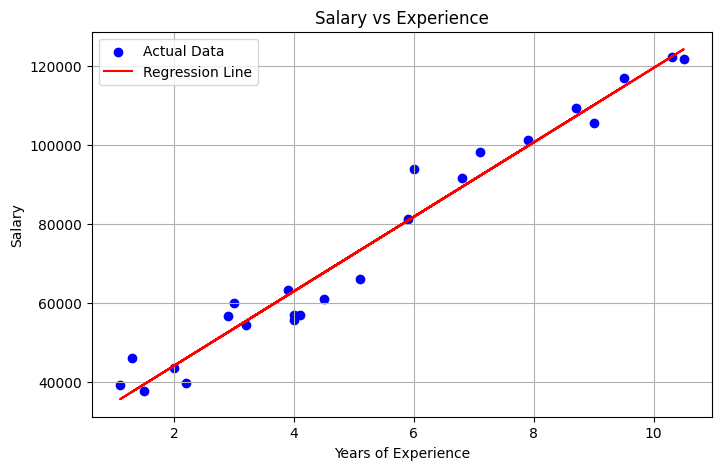

In [75]:
plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, color="blue", label="Actual Data")

plt.plot(
    X_train,
    model.predict(X_train),
    color="red",
    label="Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Experience")
plt.legend()
plt.grid(True)
plt.show()

# not needed ,its just extra

# saving the model for future

In [71]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
import joblib

In [73]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [74]:
joblib.dump(model, "linear_regression_model.pkl")

['linear_regression_model.pkl']

# Save the Model

## What is Saving a Model?

After training a Machine Learning model, we can **save the trained model** to a file. This allows us to use the model later without training it again.

In Python, the **Joblib** library is commonly used to save and load Scikit-learn models.

---

## Why Do We Save a Model?

Training a Machine Learning model can take time, especially when working with large datasets.

Instead of training the model every time we want to make predictions, we can:

- Train the model once.
- Save the trained model.
- Load the model whenever needed.
- Use it directly for prediction.

This saves both **time** and **computing resources**.

---

## Real-World Example

Suppose a company builds a salary prediction system.

### Day 1

A Data Scientist trains the Linear Regression model using employee salary data.

```python
model.fit(X_train, y_train)
```

After training, the model is saved to a file.

```python
import joblib

joblib.dump(model, "linear_regression_model.pkl")
```

---

### Day 100

A new employee joins the company with **8 years of experience**.

Instead of training the model again, the company simply loads the saved model.

```python
loaded_model = joblib.load("linear_regression_model.pkl")
```

Now the company can immediately predict the employee's salary.

```python
loaded_model.predict([[8]])
```

The prediction takes only a fraction of a second.

---

# Saving the Trained Model

```python
import joblib

joblib.dump(model, "linear_regression_model.pkl")
```

### Code Explanation

### `import joblib`

Imports the **Joblib** library, which is used to save and load Machine Learning models.

---

### `joblib.dump()`

The `dump()` function saves the trained model to a file.

**Syntax**

```python
joblib.dump(model, "filename.pkl")
```

- `model` → The trained Machine Learning model.
- `"linear_regression_model.pkl"` → The filename where the model will be stored.

After executing the code, a new file named **linear_regression_model.pkl** is created in your project folder.

---

# Loading the Saved Model

```python
loaded_model = joblib.load("linear_regression_model.pkl")
```

### Code Explanation

### `joblib.load()`

The `load()` function loads the previously saved model into memory.

After loading, the model behaves exactly like the original trained model.

You can directly use it for prediction without retraining.

Example:

```python
loaded_model.predict([[6]])
```

---

# Advantages of Saving a Model

- No need to retrain the model every time.
- Saves time and computational resources.
- Makes deployment easier.
- Useful for web applications, APIs, and production systems.
- Ensures the same trained model is used consistently.

---

# Without Saving vs With Saving

| Without Saving the Model | With Saving the Model |
|--------------------------|------------------------|
| Train the model every time | Train only once |
| Takes more time | Saves time |
| Uses more computing resources | More efficient |
| Not practical for deployment | Ideal for real-world applications |
| Model is lost when the notebook is closed | Model can be reused anytime |

---

# Is Saving the Model Mandatory?

**No.**

For learning **Simple Linear Regression**, saving the model is **optional**.

However, in real-world Machine Learning projects, saving the trained model is considered a **best practice** because it allows the model to be reused without retraining.

---

# Conclusion

Saving a trained Machine Learning model is an important step for deploying models in real-world applications. Although it is optional for learning purposes, it becomes essential in production systems where models need to make predictions efficiently without being trained again.